#### Dataset Exploration

Analyze the structure of the dataset and separate its components into csv

In [10]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("acon96/Home-Assistant-Requests")
df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

In [11]:
display(df_train.head())

,conversations
0,"[{'from': 'system', 'value': 'You are 'Al', a ..."
1,"[{'from': 'system', 'value': 'You are 'Al', a ..."
2,"[{'from': 'system', 'value': 'You are 'Al', a ..."
3,"[{'from': 'system', 'value': 'You are 'Al', a ..."
4,"[{'from': 'system', 'value': 'You are 'Al', a ..."


In [12]:
def extract_action_type(conversation_list):
    text = str(conversation_list)
    # Basic logic to find the service call within the generated text block
    if '"service":' in text:
        return "Home Assistant Service Call"
    return "Standard Conversational Reply"

df_train['action_type'] = df_train['conversations'].apply(extract_action_type)
df_test['action_type'] = df_test['conversations'].apply(extract_action_type)

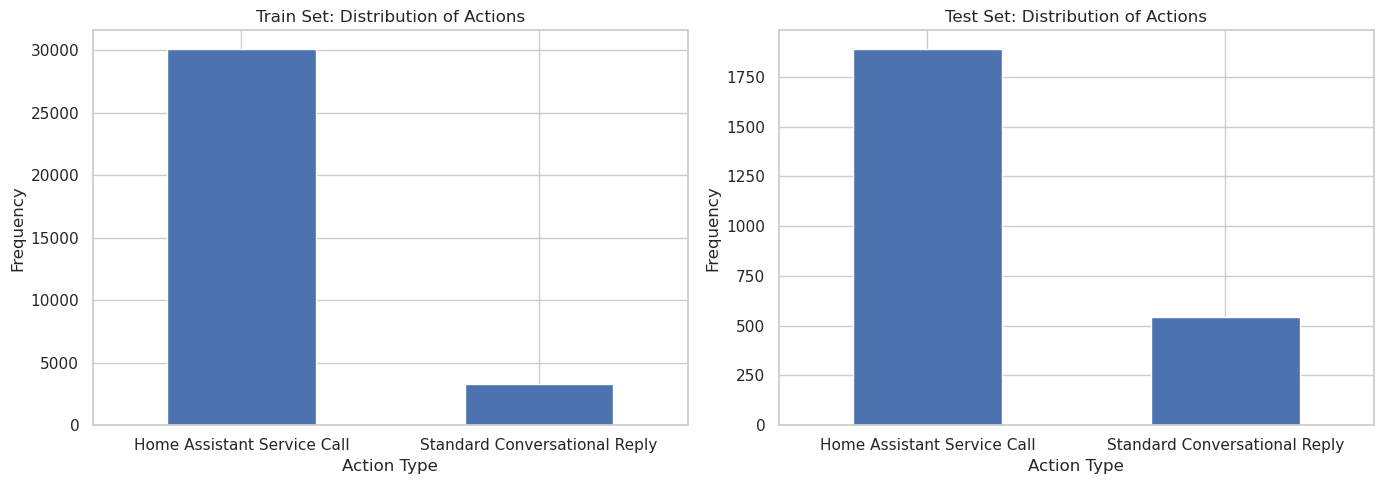

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train['action_type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Train Set: Distribution of Actions')
axes[0].set_xlabel('Action Type')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=0)

df_test['action_type'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Test Set: Distribution of Actions')
axes[1].set_xlabel('Action Type')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
import json
import re

def sanitize_string(text):
    if not isinstance(text, str):
        return ""
    # Replace newlines with spaces to prevent row-breaking in CSVs
    text = text.replace('\n', ' ').replace('\r', ' ')
    # Clean up weird trailing triple quotes if they exist in the raw data
    text = text.replace('"""', '"').replace("'''", "'")
    return text.strip()

def extract_data(data_split):
    rows = []
    for row in data_split:
        conversations = row.get("conversations", [])
        if not conversations or not isinstance(conversations, list) or not re.search(r"You are 'Al'", conversations[0].get("value", "")):
            continue
        command = None
        for turn in conversations:
            role = turn.get("from")
            text = turn.get("value", "")
            if role == "user":
                command = sanitize_string(text)
            elif role == "assistant" and command is not None:
                domain, service, entity = None, None, None
                match = re.search(r'```homeassistant\n(.*?)\n```', text, re.DOTALL)
                if match:
                    json_str = sanitize_string(match.group(1))
                    pre_text = sanitize_string(text[:match.start()])
                    try:
                        payload = json.loads(json_str)
                        service_call = payload.get("service", "")
                        if isinstance(service_call, str) and "." in service_call:
                            domain = service_call.split(".")[0]
                            service = service_call
                        entity_id = payload.get("target_device")
                        if isinstance(entity_id, str):
                            entity = entity_id
                        elif isinstance(entity_id, list) and len(entity_id) > 0:
                            entity = entity_id[0] # take first for simplicity in plotting
                    except json.JSONDecodeError:
                        pass
                    rows.append({
                        "User_Command": command,
                        "Assistant_Text": pre_text,
                        "Assistant_Payload": json_str,
                        "Domain": domain,
                        "Service": service,
                        "Entity": entity
                    })
                else:
                    rows.append({
                        "User_Command": command,
                        "Assistant_Text": sanitize_string(text),
                        "Assistant_Payload": "{}",
                        "Domain": None,
                        "Service": None,
                        "Entity": None
                    })
                command = None  # Reset after matching for the next turn
    return rows

all_rows = extract_data(dataset["train"]) + extract_data(dataset["test"])
df_all = pd.DataFrame(all_rows)
df_all = df_all.drop_duplicates(subset=["User_Command", "Assistant_Text", "Assistant_Payload"]).reset_index(drop=True)
unique_commands = df_all['User_Command'].unique()
train_cmds, test_cmds = train_test_split(unique_commands, test_size=0.2, random_state=42)
df_raw_train = df_all[df_all['User_Command'].isin(train_cmds)].reset_index(drop=True)
df_raw_test = df_all[df_all['User_Command'].isin(test_cmds)].reset_index(drop=True)
train_set_check = set(df_raw_train['User_Command'].unique())
test_set_check = set(df_raw_test['User_Command'].unique())
intersection = train_set_check.intersection(test_set_check)

In [15]:
assert len(intersection) == 0, f"FATAL ERROR: Data Leakage detected! {len(intersection)} overlapping commands."
print("0 overlapping lexical commands between Train and Test sets.")
print(f"Train Set Size: {len(df_raw_train)} rows")
print(f"Test Set Size:  {len(df_raw_test)} rows")

0 overlapping lexical commands between Train and Test sets.
Train Set Size: 13432 rows
Test Set Size:  3550 rows


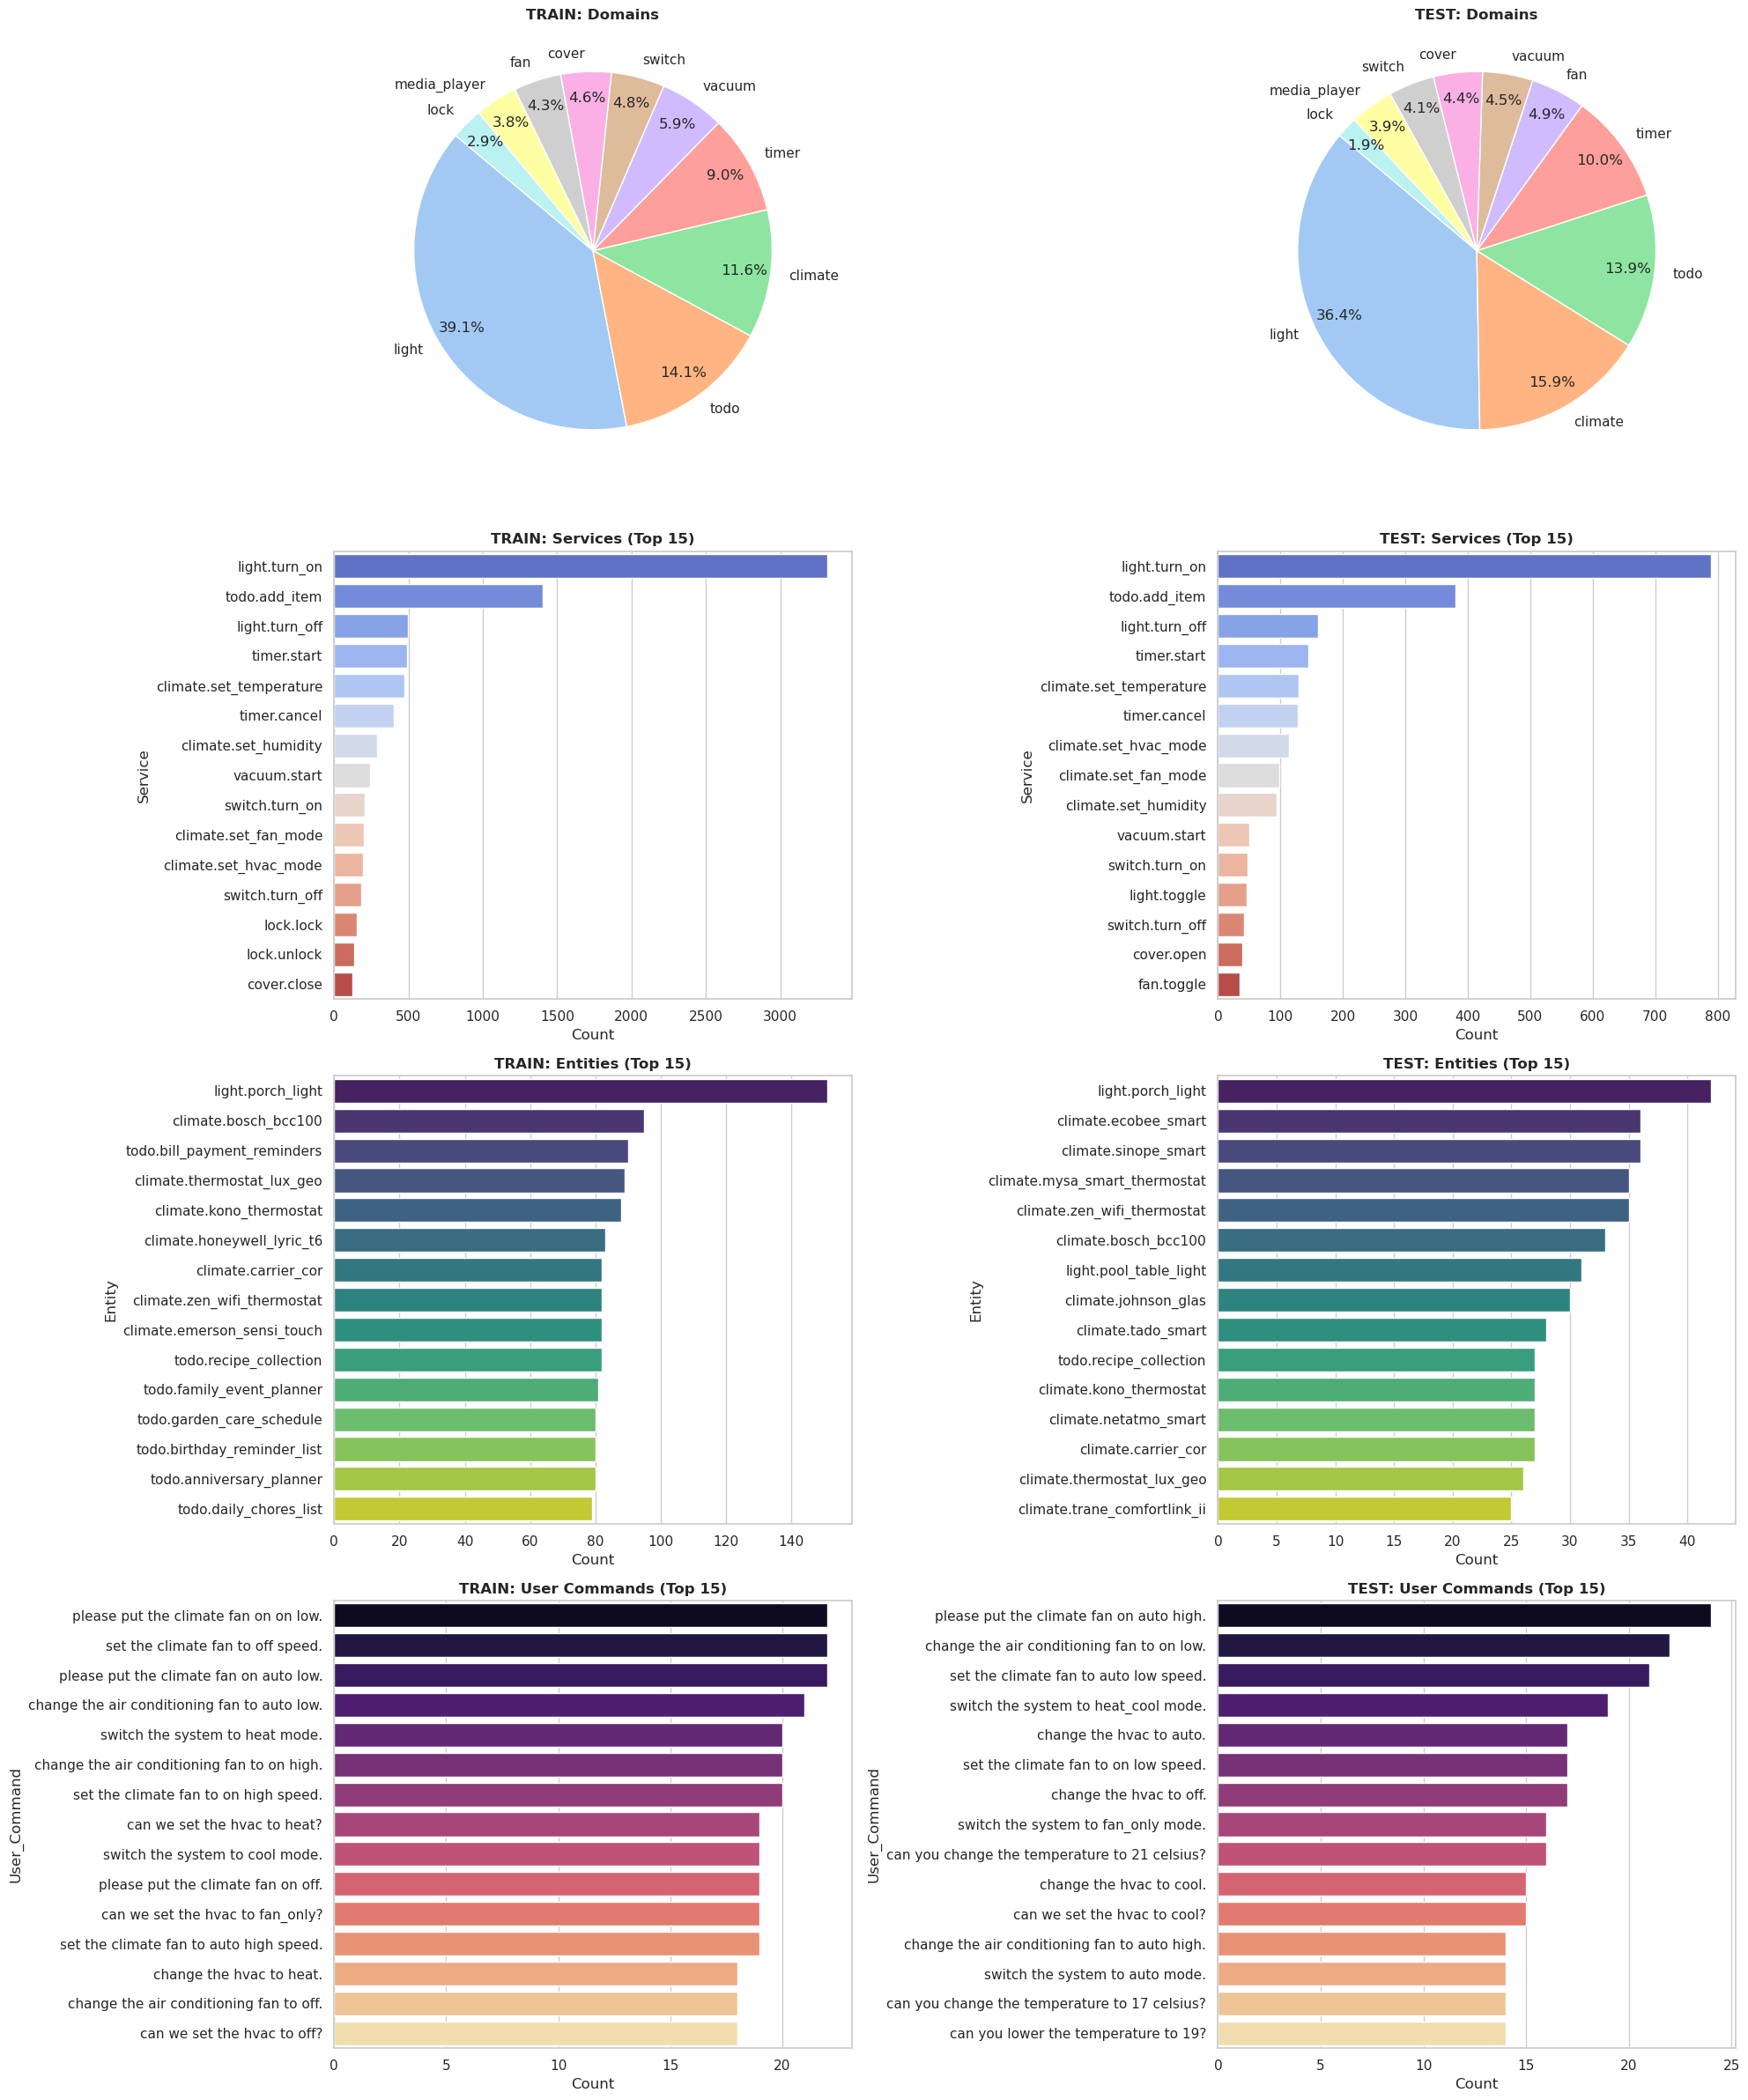

In [16]:
import seaborn as sns

def get_items(df, col):
    return df[col].dropna().value_counts()

# Collect plotting metrics for Train
dom_train = get_items(df_raw_train, 'Domain')
svc_train = get_items(df_raw_train, 'Service')
ent_train = get_items(df_raw_train, 'Entity')
cmd_train = get_items(df_raw_train, 'User_Command')

# Collect plotting metrics for Test
dom_test = get_items(df_raw_test, 'Domain')
svc_test = get_items(df_raw_test, 'Service')
ent_test = get_items(df_raw_test, 'Entity')
cmd_test = get_items(df_raw_test, 'User_Command')

PLOT_LIMIT = 15
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(20, 24))

def plot_bar(data, ax, title, color_palette="viridis", limit=PLOT_LIMIT):
    if data.empty:
        ax.text(0.5, 0.5, "No Data", ha='center')
        return
    subset = data.head(limit)
    sns.barplot(x=subset.values, y=subset.index, ax=ax, palette=color_palette, hue=subset.index, legend=False)
    ax.set_title(f"{title} (Top {limit})", fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')

def plot_pie(data, ax, title):
    if data.empty:
        ax.text(0.5, 0.5, "No Data", ha='center')
        return
    if len(data) > 15:
        top_slice = data.head(15)
        others = pd.Series([data.iloc[15:].sum()], index=['Others'])
        data_to_plot = pd.concat([top_slice, others])
    else:
        data_to_plot = data
    ax.pie(data_to_plot.values, labels=data_to_plot.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"), pctdistance=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')

# Row 0: Domains
# Row 0: Domains
plot_pie(dom_train, axes[0, 0], 'TRAIN: Domains')
plot_pie(dom_test, axes[0, 1], 'TEST: Domains')
# Row 1: Services
plot_bar(svc_train, axes[1, 0], 'TRAIN: Services', "coolwarm")
plot_bar(svc_test, axes[1, 1], 'TEST: Services', "coolwarm")
# Row 2: Entities
plot_bar(ent_train, axes[2, 0], 'TRAIN: Entities', "viridis")
plot_bar(ent_test, axes[2, 1], 'TEST: Entities', "viridis")
# Row 3: User Commands
plot_bar(cmd_train, axes[3, 0], 'TRAIN: User Commands', "magma")
plot_bar(cmd_test, axes[3, 1], 'TEST: User Commands', "magma")

plt.tight_layout()
plt.show()

In [17]:
import os
import csv

os.makedirs("./data", exist_ok=True)

df_export_train = df_raw_train.drop(columns=["Domain", "Service", "Entity"])
df_export_test = df_raw_test.drop(columns=["Domain", "Service", "Entity"])
df_export_train.index.name = 'id'
df_export_test.index.name = 'id'

df_export_train.to_csv(
    "./data/cleaned_raw_train.csv",
    index=True,
    quoting=csv.QUOTE_ALL,
    escapechar='\\'
)
df_export_test.to_csv(
    "./data/cleaned_raw_test.csv",
    index=True,
    quoting=csv.QUOTE_ALL,
    escapechar='\\'
)